In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import sys
import pickle

from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from upsetplot import UpSet, from_contents

import functools

### Helper functions

In [2]:
def get_pickle_data(pickle_path, function, params=None):
    if os.path.exists(pickle_path):
        with open(pickle_path, 'rb') as file:
            data = pickle.load(file)
    else:
        data = function(*params)
        with open(pickle_path, 'wb') as f:
            pickle.dump(data, f)
    return data

In [3]:
def plot_histogram_with_stats(values, title='Histogram', bins='auto', density=False, x_range=None):
    """
    Generate a histogram from a list of values and display a stats box.

    Parameters:
    - values: list or array of numeric data
    - title: title of the plot
    - bins: number of histogram bins
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    min_val = np.min(values)
    max_val = np.max(values)
    
    if not x_range:
        x_range = (min_val, max_val)
    
    # Plot histogram
    ax.hist(values, bins=bins, density=density, range=x_range, color='skyblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

    # Calculate stats
    mean_val = np.mean(values)
    std_val = np.std(values)

    # Prepare stats text
    stats_lines = [
        f"Min: {min_val:.2f}",
        f"Max: {max_val:.2f}",
        f"Mean: {mean_val:.2f}",
        f"Std: {std_val:.2f}"
    ]
    stats_text = "\n".join(stats_lines)
    
    # Determine font size based on number of stats lines
    font_size = max(8, min(10, 10 - len(stats_lines) // 2))

    # Add stats box to the plot
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)

    plt.show()


# Data Exploration
Raw recieved data from `zasilka-TP4VGT9M89DDMFIM` are split and concatenated in such a way so we now I a .csv file per one water meter (per id).

Script `split_and_concat_dfs.py` is used for this purpose.

Finished data is in `data` folder.

In this notebook data will be examined.

## Example Water Meter 

In [4]:
example_df = pd.read_csv("./data/2328.csv")
example_df.tail()

,id,timestamp,hodnota
3102,2328,2020-08-05 10:23:19,522.047
3103,2328,2020-08-05 11:23:20,522.053
3104,2328,2020-08-05 11:53:18,522.053
3105,2328,2020-08-05 12:23:18,522.054
3106,2328,2020-08-05 14:53:19,522.058


In [5]:
example_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         3107 non-null   int64  
 1   timestamp  3107 non-null   object 
 2   hodnota    3107 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 72.9+ KB


## Number of Water Meters

In [6]:
all_dfs_paths = [f"./data/{filename}" for filename in os.listdir('data')] 
print(f"Total number of Water Meters: {len(all_dfs_paths)}")

Total number of Water Meters: 27603


## Timestamp not sorted
We see that some timestamp values are not sorted, let's examine that

### Check Sorting
Check if all values in `timestamp` and `hodnota` column are sorted.

We sort all df based on `timestamp` but many values stay unsorted based on `hodnota`. Let examine them

In [7]:
def get_unsorted_filepaths_timestamp(folder = './data'):

    unsorted_filepaths_timestamp = []

    for filename in os.listdir(folder):
        if filename.endswith('.csv'):
            filepath = os.path.join(folder, filename)
            df = pd.read_csv(filepath)
            df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            if not df['timestamp'].dropna().is_monotonic_increasing:
                #print(f"File not sorted: {filename}")
                unsorted_filepaths_timestamp.append(filepath)

    return unsorted_filepaths_timestamp

In [8]:
unsorted_filepaths_timestamp = get_pickle_data('./pickles/unsorted_filepaths_timestamp.pkl', get_unsorted_filepaths_timestamp, './data')
print(f"Number of files that contain unsorted timestamp: {len(unsorted_filepaths_timestamp)}")

Number of files that contain unsorted timestamp: 3710


In [9]:
def get_unsorted_filepaths_timestamp_and_hodnota(unsorted_filepaths_timestamp):
    unsorted_filepaths_timestamp_and_hodnota = {}
    
    for filepath in unsorted_filepaths_timestamp:
        df = pd.read_csv(filepath)

        timestamp_col = 'timestamp'
        df[timestamp_col] = pd.to_datetime(df[timestamp_col])

        unsorted_indices = df.index[df[timestamp_col].diff() < pd.Timedelta(0)].tolist()

        unsorted_hodnota_indeces = []
        for idx in unsorted_indices:
            if df.iloc[idx-1]['hodnota'] - df.iloc[idx]['hodnota'] <= 0:
                unsorted_hodnota_indeces.append(idx)
                #print(df.iloc[idx-1:idx+1])

        if unsorted_hodnota_indeces:
            unsorted_filepaths_timestamp_and_hodnota[filepath] = unsorted_hodnota_indeces
        
    return unsorted_filepaths_timestamp_and_hodnota

In [10]:
unsorted_filepaths_timestamp_and_hodnota = get_pickle_data('./pickles/unsorted_filepaths_timestamp_and_hodnota.pkl', get_unsorted_filepaths_timestamp_and_hodnota, [unsorted_filepaths_timestamp])

print(f"Number of files that contain unsorted timestamp where also the hodnota doesn't match: {len(unsorted_filepaths_timestamp_and_hodnota)}")
total_indices = sum(len(v) for v in unsorted_filepaths_timestamp_and_hodnota.values())
print(f"Total number of indices: {total_indices}")

Number of files that contain unsorted timestamp where also the hodnota doesn't match: 3706
Total number of indices: 7585


In [11]:
i = 0
for filepath, indices in unsorted_filepaths_timestamp_and_hodnota.items():
    df = pd.read_csv(filepath)
    for idx in indices:
        print(df.iloc[idx-1:idx+2])
    if i > 10:
        break
    i += 1

          id            timestamp  hodnota
6534  100038  2021-10-31 02:30:00      0.0
6535  100038  2021-10-31 02:00:00      0.0
6536  100038  2021-10-31 03:00:00      0.0
          id            timestamp  hodnota
9160  100038  2023-10-29 02:30:00      0.0
9161  100038  2023-10-29 02:00:00      0.0
9162  100038  2023-10-29 03:00:00      0.0
           id            timestamp  hodnota
12414  100038  2024-10-27 02:30:00      0.0
12415  100038  2024-10-27 02:00:00      0.0
12416  100038  2024-10-27 03:30:00      0.0
          id            timestamp  hodnota
6578  100039  2021-10-31 02:30:00    1.608
6579  100039  2021-10-31 02:00:00    1.608
6580  100039  2021-10-31 03:00:00    1.608
           id            timestamp  hodnota
23807  100039  2022-10-30 02:30:00    3.078
23808  100039  2022-10-30 02:00:00    3.078
23809  100039  2022-10-30 03:00:00    3.078
           id            timestamp  hodnota
30221  100039  2024-10-27 02:30:00    6.701
30222  100039  2024-10-27 02:00:00    6.701


### When is ti not true that timestamp doesnt macth but values matches 
since this is only occuring in 4 case

In [12]:
for filepath in unsorted_filepaths_timestamp:
    
    if filepath in unsorted_filepaths_timestamp_and_hodnota:
        continue
    df = pd.read_csv(filepath)

    timestamp_col = 'timestamp'
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    
    unsorted_indices = df.index[df[timestamp_col].diff() < pd.Timedelta(0)].tolist()
    
    for idx in unsorted_indices:
        print(df.iloc[idx-1:idx+1])
    

          id           timestamp  hodnota
9382  133481 2024-10-27 02:40:00  137.678
9383  133481 2024-10-27 02:00:00  137.677
          id           timestamp     hodnota
4293  138323 2024-10-27 02:30:00  999309.925
4294  138323 2024-10-27 02:00:00  999309.859
          id           timestamp  hodnota
4339  138888 2024-10-27 02:52:50  190.272
4340  138888 2024-10-27 02:22:50  190.270
      id           timestamp  hodnota
0  91246 2023-01-23 18:04:50   28.818
1  91246 2023-01-01 00:05:08   27.980


### Swap timestamps where values doesnt match
Timestamp values will be swaped where they dont match. If they dont match only in timestamp col then only the timestamp column values are swapped. If they dont match in both the timestamp col and the value column (the case of the 4 meters) swap the whole row.

Swapping is done in `create_diff.py` under func `sort_dfs_timestamp`.

## Check how `hodnota` is sorted

In [13]:
unsorted_values_dfs_dir = './data_sorted_timestamp_decrease_value/'
unsorted_values_dfs_paths = os.listdir('./data_sorted_timestamp_decrease_value/')

print(f"Number of files where values sorting doesn't match after sorting timestamp: {len(unsorted_values_dfs_paths)} out of {len(all_dfs_paths)}")

Number of files where values sorting doesn't match after sorting timestamp: 1765 out of 27603


In [14]:
random_unsorted_df = pd.read_csv(f"{unsorted_values_dfs_dir}/{unsorted_values_dfs_paths[200]}")
unsorted_indices = random_unsorted_df.index[random_unsorted_df["hodnota"].diff() < -0.000].tolist()

for idx in unsorted_indices:
    print(random_unsorted_df.iloc[idx-1:idx+1])
#for df_path in unsorted_values_dfs_paths:

           id            timestamp  hodnota
52131  107977  2024-09-18 23:21:02  145.659
52132  107977  2024-09-18 23:27:02  131.084
           id            timestamp  hodnota
57017  107977  2024-12-11 22:21:05  156.526
57018  107977  2024-12-11 22:27:05  126.415
           id            timestamp  hodnota
66856  107977  2025-06-02 08:23:51  177.076
66857  107977  2025-06-02 08:40:09  177.070
           id            timestamp  hodnota
67222  107977  2025-06-08 20:53:23  177.767
67223  107977  2025-06-08 21:15:49  177.765


In [15]:
def diff_bigger_than(df_filename: str, difference = -0.002) -> int:
    df = pd.read_csv(f"{unsorted_values_dfs_dir}/{df_filename}")
    
    unsorted_indices = df.index[df["hodnota"].diff() < difference].tolist()
    return df_filename, unsorted_indices

def files_bigger_than(file_paths: list, difference) -> dict:
    return dict(map(lambda filename: diff_bigger_than(filename, difference=difference), file_paths))

In [16]:
unsorted_indeces_all_files_diff_002 = get_pickle_data('./pickles/unsorted_idxs_all_files_diff_002', files_bigger_than, [unsorted_values_dfs_paths, -0.002])
unsorted_indeces_all_files_diff_000 = get_pickle_data('./pickles/unsorted_idxs_all_files_diff_000', files_bigger_than, [unsorted_values_dfs_paths, 0])

In [17]:
empty_indices_filenames_002 = [filename for filename, indices in unsorted_indeces_all_files_diff_002.items() if len(indices) == 0]
empty_indices_filenames_000 = [filename for filename, indices in unsorted_indeces_all_files_diff_000.items() if len(indices) == 0]
print(f"Number of files that have unsorted indices with difference bigger than 0.002: {len(unsorted_indeces_all_files_diff_000) - len(empty_indices_filenames_002)}")

Number of files that have unsorted indices with difference bigger than 0.002: 1458


In [18]:
num_unsort_idxs_002 = sum(len(unsorted_indices_value) for unsorted_indices_value in unsorted_indeces_all_files_diff_002.values())
num_unsort_idxs_000 = sum(len(unsorted_indices_value) for unsorted_indices_value in unsorted_indeces_all_files_diff_000.values())

print(f"Total number of unsorted indexes in all files is {num_unsort_idxs_000}")
print(f"If we allow 0.002 diff tolerance then it is {num_unsort_idxs_002}")

Total number of unsorted indexes in all files is 88888
If we allow 0.002 diff tolerance then it is 47806


In [19]:
def count_unsorted_after_date(df_filename: str, unsorted_indices: list, date_str="2024-01-01") -> int:
    df = pd.read_csv(f"{unsorted_values_dfs_dir}/{df_filename}")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    cutoff_date = pd.to_datetime(date_str)
    
    filtered_indices = [idx for idx in unsorted_indices if df.loc[idx, "timestamp"] > cutoff_date]
    return len(filtered_indices)

def sum_after_date(unsorted_indices_dict, date_str="2024-01-01"):
    return sum(
        count_unsorted_after_date(filename, indices, date_str) 
        for filename, indices in unsorted_indices_dict.items()
    )

In [20]:
total_after_date_002 = get_pickle_data('./pickles/total_after_date_002.pkl', sum_after_date, [unsorted_indeces_all_files_diff_002]) 
total_after_date_000 = get_pickle_data('./pickles/total_after_date_000.pkl', sum_after_date, [unsorted_indeces_all_files_diff_000]) 

print(f"Total unsorted indices after 2024-01-01: {total_after_date_000}")
print(f"If we allow 0.001 tolerance: {total_after_date_002}")

Total unsorted indices after 2024-01-01: 65785
If we allow 0.001 tolerance: 33303


Since we havent managed to figure out how to deal with the unsorted `hodnota` values the `Diff` values are calculated regardless but when the value would be negative a NaN value is added.

## Create Diff

`Diff` column in added in `create_diff.py` file.

Create column with values equal to `df[hodnota][t]` - `df[hodnota][t-1]`.

Since we havent managed to figure out how to deal with the unsorted `hodnota` values the `Diff` values are calculated regardless but when the value would be negative a NaN value is added.

In [21]:
example_df = pd.read_csv('./data_sorted_timestamp/111227.csv')
example_df.head()

,id,timestamp,hodnota,Diff
0,111227,2022-04-21 05:03:01,0.200,0.000
1,111227,2022-04-25 16:46:32,38.142,37.942
2,111227,2022-04-25 17:46:49,38.568,0.426
3,111227,2022-04-25 19:47:24,39.679,1.111
4,111227,2022-04-25 22:48:17,42.142,2.463


## Add Metadata

New folder called `metadata` created where metadata (json files) are placed. Each file has the same name as a corresponding water meter ID.

Metadata are created in file `create_metadata.py`

In [22]:
import json

with open("metadata/111227.json", 'r') as f:
    example_metadata = json.load(f)
    
print(example_metadata)

{'num_records': 9288, 'start_time': '2022-04-21 05:03:01', 'end_time': '2025-10-07 23:17:49', 'value_min': 0.2, 'value_max': 10355.422, 'value_mean': 4633.054635874247, 'value_std': 3414.5943346175854, 'diff_min': 0.0, 'diff_max': 320.029, 'diff_mean': 1.1149033161068045, 'diff_std': 5.182698632616613, 'nan_value_count': 0, 'nan_diff_count': 0, 'common_periodicity_seconds': 3617.0, 'num_gaps_5min': 4224, 'num_gaps_10percent': 4222, 'proportion_of_gaps_5min': 0.45478036175710596, 'proportion_of_gaps_10percent': 0.4545650301464255}


## Number of Records
Histogram of number of records

In [23]:
def metadata_to_list(key_name, folder='./metadata') -> list:
    '''
    Returns a list with metadata values of a given key values in parameter
    '''
    res = []
    
    for json_file in os.listdir(folder):
        json_path = os.path.join(folder, json_file)
        try:
            with open(json_path, 'r') as f:
                metadata =  json.load(f)
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON file {json_path}: {e}", file=sys.stderr)
            raise
        
        res.append(metadata[key_name])
    
    return res

def metadata_to_dict(key_name, folder='./metadata') -> dict:
    '''
    Returns a dict with metadata values of a given key values in parameter
    '''
    res = {}
    
    for json_file in os.listdir(folder):
        json_path = os.path.join(folder, json_file)
        try:
            with open(json_path, 'r') as f:
                metadata =  json.load(f)
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON file {json_path}: {e}", file=sys.stderr)
            raise
        
        res[json_file] = metadata[key_name]
    
    return res

In [24]:
number_of_records = get_pickle_data('./pickles/number_of_records', metadata_to_list, ['num_records'])

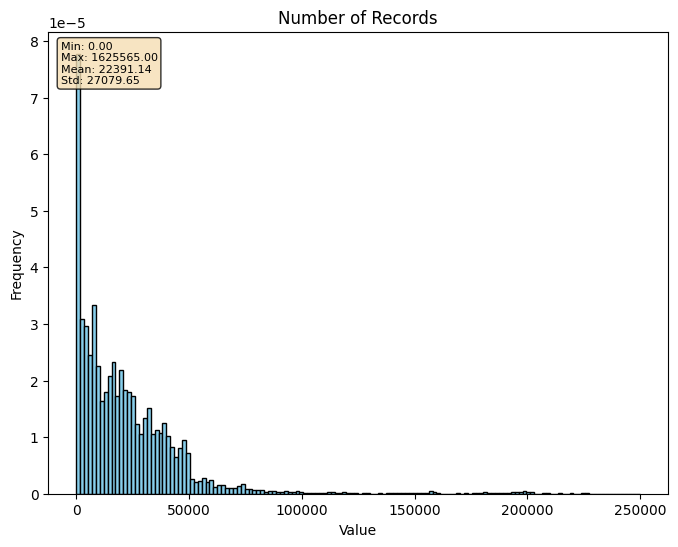

In [25]:
plot_histogram_with_stats(number_of_records, title='Number of Records', density=True, x_range=(0, 0.25e6))

## Duration
Examine duration of measurements on the meter

In [26]:
def get_datetimes(dates: list) -> list:
    datetime_dates = []
    
    for date in dates:
        try:
            date = pd.to_datetime(date, format='%Y-%m-%d %H:%M:%S')
        except ValueError:
            date = pd.to_datetime(date, format='%Y-%m-%d')
        
        datetime_dates.append(date)
        
    return datetime_dates

In [27]:
start_dates = get_pickle_data('./pickles/start_dates.pkl', metadata_to_dict, ['start_time'])
end_dates = get_pickle_data('./pickles/end_dates.pkl', metadata_to_dict, ['end_time'])


In [28]:
start_dates = dict(zip(start_dates.keys(), get_datetimes(start_dates.values())))
end_dates = dict(zip(end_dates.keys(), get_datetimes(end_dates.values())))

start_series = pd.Series({k: start_dates[k] for k in start_dates.keys()})
end_series = pd.Series({k: end_dates[k] for k in end_dates.keys()})

durations = end_series - start_series
durations_in_days = durations.dt.total_seconds() / (3600 * 24)

durations_in_days_dict = durations_in_days.to_dict()

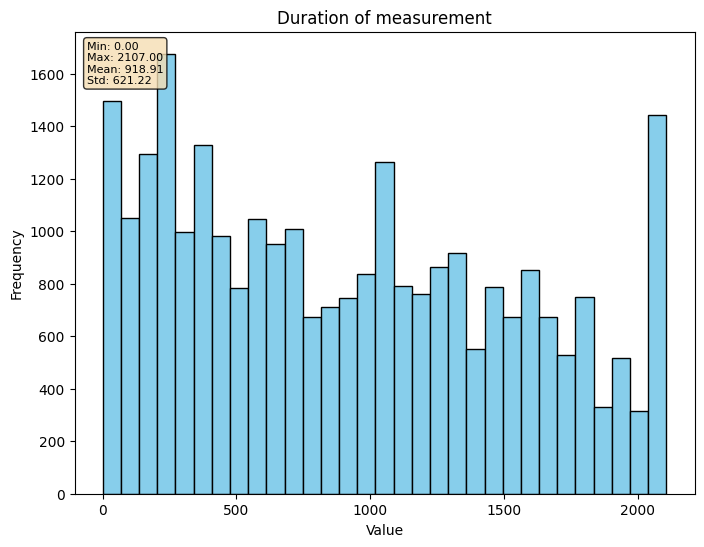

In [29]:
plot_histogram_with_stats(durations_in_days, "Duration of measurement")

As we can see, we get many durations. Some lasting less then a year but some over multiple years.

In [30]:
def is_active(end_date) -> bool:
    '''
    Returns True if water meter contains data from September 2025, else False
    '''
    september_date = datetime.strptime("2025-09-01", "%Y-%m-%d")
    return end_date >= september_date

active_meter_filenames = [filename for filename, end_date in end_dates.items() if is_active(end_date)]
print(f"Number of meters that are active as of September 2025: {len(active_meter_filenames)} out of total {len(all_dfs_paths)}")

Number of meters that are active as of September 2025: 24468 out of total 27603


## NaN values in Diff and hodnota

In [31]:
nan_value_counts = get_pickle_data('./pickles/hodnota_nans.pkl', metadata_to_dict, ['nan_value_count'])
nan_diff_counts = get_pickle_data('./pickles/diff_nans.pkl', metadata_to_dict, ['nan_diff_count'])

In [32]:
filenames_no_nan_hodnota = [filename for filename, nan_count in nan_value_counts.items() if nan_count != 0]
filenames_no_nan_diff = [filename for filename, nan_count in nan_diff_counts.items() if nan_count != 0]
filenames_min5_nan_less_diff = [filename for filename, nan_count in nan_diff_counts.items() if nan_count > 5]

print(f"Number of files that contain NaN values in the Value column; {len(filenames_no_nan_hodnota)}")
print(f"Number of files that contain NaN values in the Diff column; {len(filenames_no_nan_diff)}")
print(f"Number of files that contain more than 5 NaN values in the Diff column; {len(filenames_min5_nan_less_diff)}")

Number of files that contain NaN values in the Value column; 185
Number of files that contain NaN values in the Diff column; 6536
Number of files that contain more than 5 NaN values in the Diff column; 1920


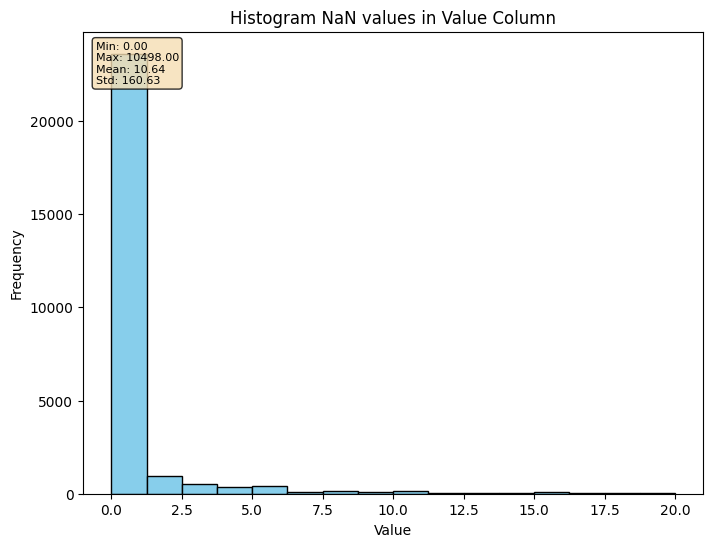

In [33]:
plot_histogram_with_stats(list(nan_diff_counts.values()), "Histogram NaN values in Value Column", x_range=(0, 20)) #some have almost all values nan

Important to note that if diff would be calculated negatively (since new values is lower then prev) we will it with NaN. If we zoom out the histogram we see that some files have almost only nan values

## Periodicity

In [34]:
periodicities = get_pickle_data('./pickles/periodicities.pkl', metadata_to_dict, ['common_periodicity_seconds'])
valid_periodicities = {filename: periodicity for filename, periodicity in periodicities.items() if periodicity is not None}

print(f"Number of meters where we could not determine a periodicity: {len(periodicities) - len(valid_periodicities)}")

Number of meters where we could not determine a periodicity: 160


Number of meters that have estimated periodicity over a day: 1049


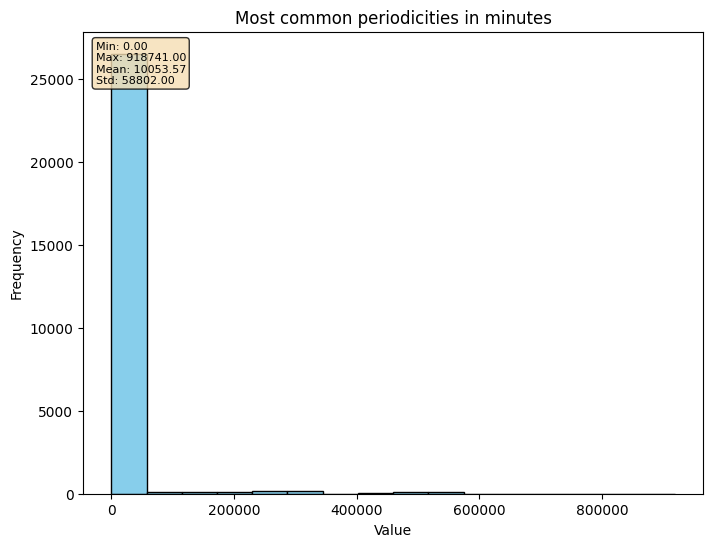

In [35]:
periodicities_in_minutes = [val / 60 for val in valid_periodicities.values()]
periodicities_in_minutes_rounded = [round(val, 0) for val in periodicities_in_minutes]

print(f"Number of meters that have estimated periodicity over a day: {len([p for p in periodicities_in_minutes_rounded if p > (60*24 + 5)])}")

plot_histogram_with_stats(periodicities_in_minutes_rounded, "Most common periodicities in minutes")


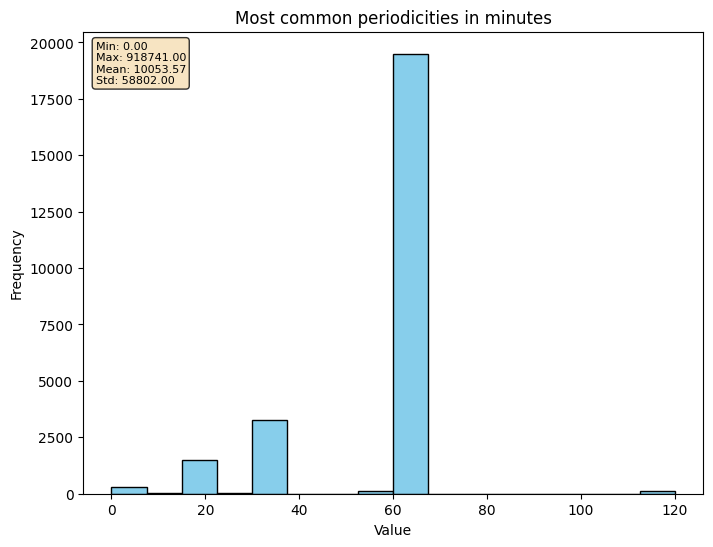

In [36]:
plot_histogram_with_stats(periodicities_in_minutes_rounded, "Most common periodicities in minutes", x_range=(0, 120))

In [37]:
num_gaps_5min = get_pickle_data('./pickles/gaps_5min.pkl', metadata_to_dict, ['num_gaps_5min'])
gaps_10percent = get_pickle_data('./pickles/gaps_10percent.pkl', metadata_to_dict, ['num_gaps_10percent'])

valid_num_gaps_5min = {filename: gap_cnt for filename, gap_cnt in num_gaps_5min.items() if filename in valid_periodicities}
valid_num_gaps_10percent = {filename: gap_cnt for filename, gap_cnt in gaps_10percent.items() if filename in valid_periodicities}

In [38]:
print(f"Number of meters that have no gaps over 5 min: {len([g for g in valid_num_gaps_5min.values() if g == 0])}")
print(f"Number of meters that have no gaps over 10 percent of period time: {len([g for g in valid_num_gaps_5min.values() if g == 0])}")

Number of meters that have no gaps over 5 min: 195
Number of meters that have no gaps over 10 percent of period time: 195


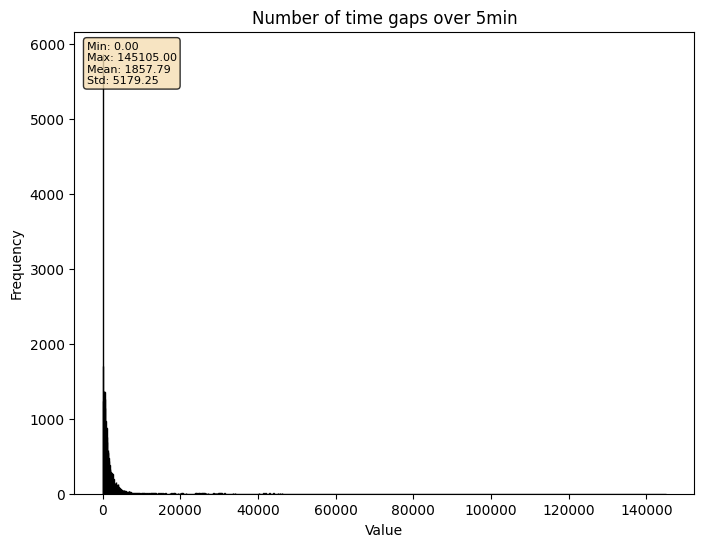

In [39]:
plot_histogram_with_stats(list(valid_num_gaps_5min.values()), "Number of time gaps over 5min")

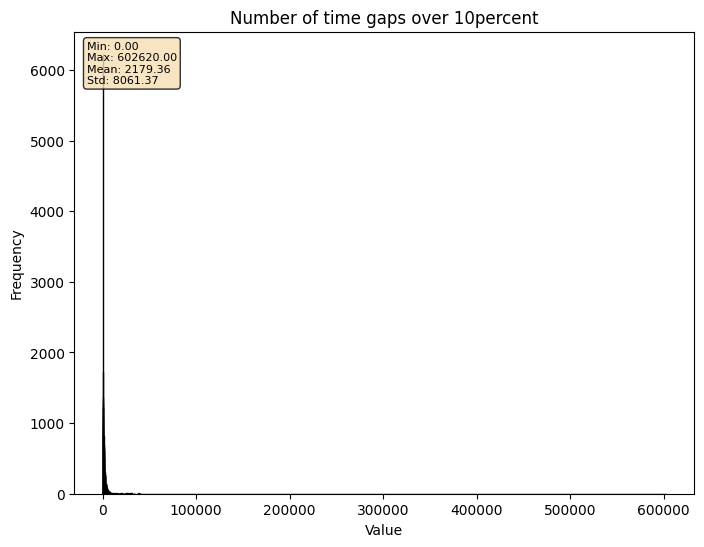

In [40]:
plot_histogram_with_stats(list(valid_num_gaps_10percent.values()), "Number of time gaps over 10percent")

In [41]:
proportion_gaps = get_pickle_data('./pickles/gaps_5min_proportion.pkl', metadata_to_dict, ['proportion_of_gaps_5min'])
valid_proportion_gaps = {filename: gap_cnt for filename, gap_cnt in proportion_gaps.items() if filename in valid_periodicities}

In [42]:
print(f"Number of meters that have less then 5 percent of time gaps: {len([g for g in valid_proportion_gaps.values() if g < 0.05])}")

Number of meters that have less then 5 percent of time gaps: 13368


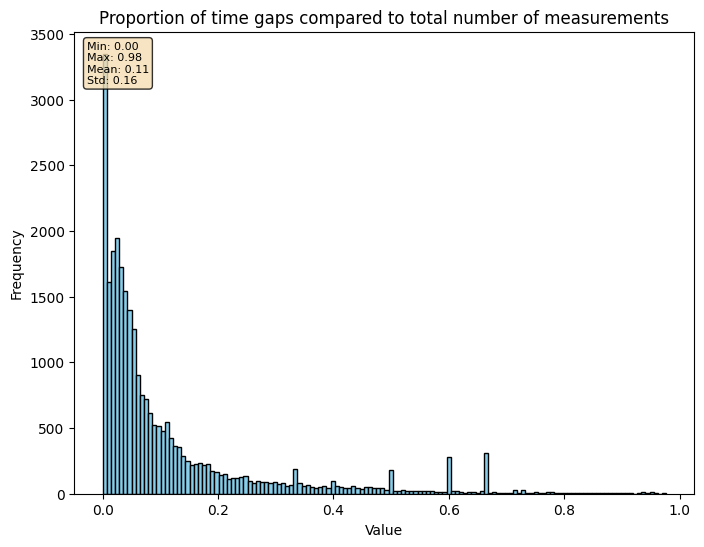

In [43]:
plot_histogram_with_stats(list(valid_proportion_gaps.values()), "Proportion of time gaps compared to total number of measurements")

## UpSet Plot

In [44]:
valid_periodicities_under_120min = [filename for filename, periodicity in valid_periodicities.items() if periodicity < (60*60*2 + 5)]
valid_proportion_gaps_under_5percent = [filename for filename, gap in valid_proportion_gaps.items() if gap < 0.05]
filenames_max5_nan_less_diff = [filename for filename, nan_count in nan_value_counts.items() if nan_count < 5]
durations_in_days_over365 = [filename for filename, duration in durations_in_days_dict.items() if duration > 365]
#active_meter_filenames

c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[

<Figure size 1200x700 with 0 Axes>

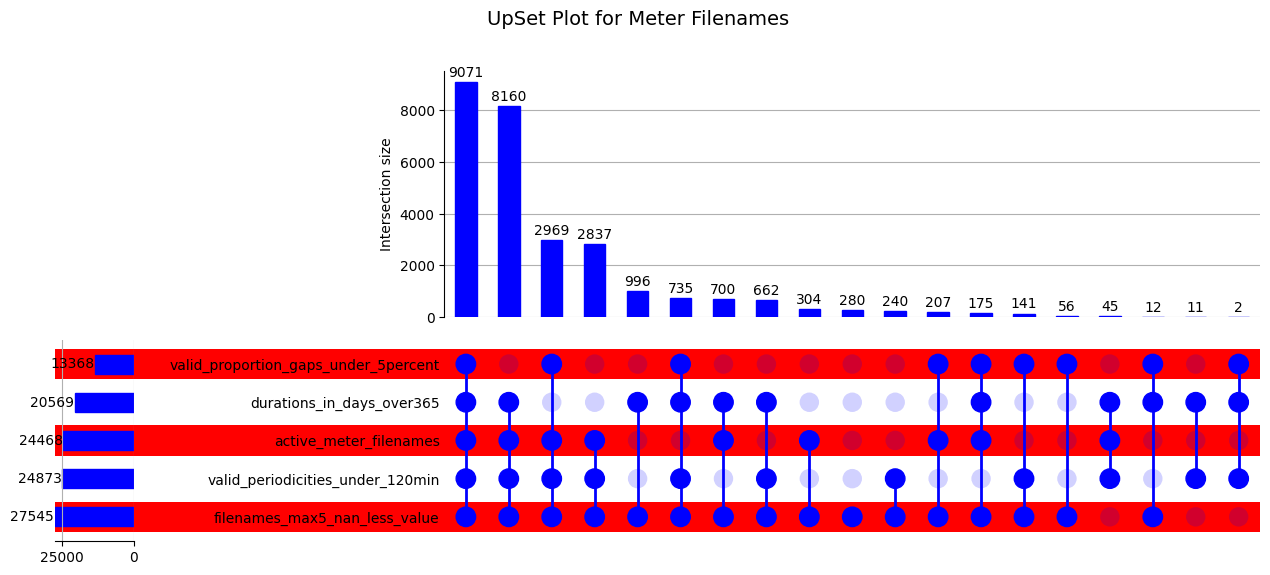

In [45]:
# Create dictionary for UpSet plot input
sets_dict = {
    'valid_periodicities_under_120min': valid_periodicities_under_120min,
    'valid_proportion_gaps_under_5percent': valid_proportion_gaps_under_5percent,
    'active_meter_filenames': active_meter_filenames,
    'filenames_max5_nan_less_value': filenames_max5_nan_less_diff,
    'durations_in_days_over365': durations_in_days_over365
}

# Convert to UpSet input format
upset_data = from_contents(sets_dict)

# Create UpSet plot with color customization
fig = plt.figure(figsize=(12, 7))
upset = UpSet(
    upset_data, 
    show_counts='%d', 
    sort_by='cardinality',
    facecolor='blue',           # Blue for intersection bars
    shading_color='red',        # Orange for set size bars
    element_size=40
)
upset.plot()

plt.suptitle('UpSet Plot for Meter Filenames', y=0.98, fontsize=14)
plt.show()